## 2 BODY PROBLEM

Firstly, we analize closed orbits, $0 \leq e<1$, that can be easily demonstrated to be elliptical and are given from the following analytical equation:

$$ 
\begin{equation}
    r=\frac{l^2}{(ecos(\theta-\theta_0)+1)GM}
\end{equation}
$$

Where $M=m_1+m_2$ is the sum of the masses of the 2 bodies and $l$ is the angular momentum per unit mass, that can be written as

$$
\begin{equation}
    l=\sqrt{aGM(1+e^2)}
\end{equation}
$$

The total energy per unit mass of the system is 

$$
\begin{equation}
    E=-\frac{GM}{2a}
\end{equation}
$$





To tackle the 2 body problem, we put ourselves in the reference frame of the center of mass.

\begin{equation}
    \vec{r_1}=\frac{m_2}{M}\vec{r}
\end{equation}

\begin{equation}
    \vec{r_2}=-\frac{m_1}{M}\vec{r}
\end{equation}

At this point, we choose to use polar coordinates and we recover equations for the velocity components from the angular momentum definition and the conservation of energy.

\begin{equation}
    v_\theta=\frac{l}{r}
\end{equation}

\begin{equation}
    v_r=\sqrt{-v_\theta^2+\frac{2GM}{r}-\frac{GM}{a}}
\end{equation}


Given a closed orbit, we can identify pericenter and apocenter.

\begin{equation}
    r_p=a(1-e)
\end{equation}

\begin{equation}
    r_a=a(1+e)
\end{equation}

To solve the problem numerically, through the code that we were given, we need to adimensionalize the equations at play, to set $G=1$ in internal units. We choose the units for time and mass and consequentially we derive the units for length.

\begin{equation}
    M \ [g] = 2   \cdot  10^{33} \ M \ [IU]
\end{equation}

\begin{equation}
    t \ [s] =  10^{6} \ t \ [IU]
\end{equation}

\begin{equation}
    r \ [cm] =  5.11  \cdot  10^{12} \ r \ [IU]
\end{equation}



To tackle the code, we need to impose some parameters and derive the initial conditions for positions and velocities of both bodies. \
Firstly, we pick $m_1$, $m_2$, $e$ and $a$, in order to identify a specific orbit. \
We choose the pericenter of the orbit as the starting point for our simulation, so we proceed to derive the positions and velocities of the two bodies.
For practical purposes, we pick the initial phase $\theta_0=0$, which means that the pericenter lays on our $x$ axis. \
Knowing the distance of the two bodies at the pericenter $r_p=a(1-e)$ in the reference frame of the center of mass, we can revert their coordinates in our reference frame and convert them from polar to cartesian. While, from the afore stated equations, we can derive the velocity components. \
Given our choices, the initial $y$ coordinate of both bodies is null and so is the initial $x$ component of both bodies velocity, since at pericenter, there's no radial velocity.

First off, we analyse the Sun-Earth orbit with the following parameters:
$$e=0.0167$$
$$a=1.5 \cdot 10^{13} \ cm$$
$$m_1= 10^{-6} M_\odot$$
$$m_2= 1 \  M_\odot$$

In [23]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
import pandas as pd

In [24]:
def cm_to_u(r_cm, L_unit_cm=5.11e12):
    """
    da cm a unità interne.
    """
    return r_cm / L_unit_cm


def u_to_cm(r_u, L_unit_cm=5.11e12):
    """
    da unità interne a cm.
    """
    return r_u * L_unit_cm


# =========================================================
# Condizioni iniziali cartesiane al pericentro
# =========================================================

def two_body_ic_pericenter(m1, m2, a, e, G=1.0):
    """
    - moto nel piano xy
    - z = vz = 0
    - il vettore relativo iniziale è lungo +x
    - la velocità relativa iniziale è lungo +y
    - frame del centro di massa

    """
    if not (0.0 <= e < 1.0):
        raise ValueError("Per orbita bound serve 0 <= e < 1.")

    M = m1 + m2

    # Distanza al pericentro
    r_p = a * (1.0 - e)

    # Velocità al pericentro
    v_p = np.sqrt(G * M * (1.0 + e) / (a * (1.0 - e)))

    # Vettori relativi cartesiani
    r_rel = np.array([r_p, 0.0, 0.0], dtype=float)
    v_rel = np.array([0.0, v_p, 0.0], dtype=float)

    # Passaggio al frame del centro di massa
    r1 = -(m2 / M) * r_rel
    r2 = +(m1 / M) * r_rel

    v1 = -(m2 / M) * v_rel
    v2 = +(m1 / M) * v_rel

    # Check utili
    eps = 0.5 * np.dot(v_rel, v_rel) - G * M / np.linalg.norm(r_rel)
    eps_theory = -G * M / (2.0 * a)
    T = 2.0 * np.pi * np.sqrt(a**3 / (G * M))

    return {
        "m1": m1,
        "m2": m2,
        "M": M,
        "a": a,
        "e": e,
        "r_p": r_p,
        "v_p": v_p,
        "r1": r1,
        "r2": r2,
        "v1": v1,
        "v2": v2,
        "r_rel": r_rel,
        "v_rel": v_rel,
        "eps": eps,
        "eps_theory": eps_theory,
        "T": T,
    }



def print_ic(ic):
    print("=== PARAMETRI ===")
    print(f"m1 = {ic['m1']}")
    print(f"m2 = {ic['m2']}")
    print(f"M  = {ic['M']}")
    print(f"a  = {ic['a']}")
    print(f"e  = {ic['e']}")
    print()

    print("=== MOTO RELATIVO ===")
    print(f"r_rel = {ic['r_rel']}")
    print(f"v_rel = {ic['v_rel']}")
    print(f"r_p   = {ic['r_p']}")
    print(f"v_p   = {ic['v_p']}")
    print()

    print("=== PARTICELLA 1 ===")
    print(f"r1 = {ic['r1']}")
    print(f"v1 = {ic['v1']}")
    print()

    print("=== PARTICELLA 2 ===")
    print(f"r2 = {ic['r2']}")
    print(f"v2 = {ic['v2']}")
    print()

    print("=== CHECK ENERGIA ===")
    print(f"eps numerica = {ic['eps']}")
    print(f"eps teorica  = {ic['eps_theory']}")
    print(f"T            = {ic['T']}")



def write_ic_file(filename, ic, t0=0.0):
    
    x1, y1, z1 = ic["r1"]
    vx1, vy1, vz1 = ic["v1"]

    x2, y2, z2 = ic["r2"]
    vx2, vy2, vz2 = ic["v2"]

    with open(filename, "w") as f:
        f.write("2\n")
        f.write(f"{t0:.16e}\n")
        f.write(
            f"{ic['m1']:.16e} {x1:.16e} {y1:.16e} {z1:.16e} "
            f"{vx1:.16e} {vy1:.16e} {vz1:.16e}\n"
        )
        f.write(
            f"{ic['m2']:.16e} {x2:.16e} {y2:.16e} {z2:.16e} "
            f"{vx2:.16e} {vy2:.16e} {vz2:.16e}\n"
        )



if __name__ == "__main__":
    # -------------------------
    # INPUT
    # -------------------------
    m1 = 1.0e-6
    m2 = 1.0
    e = 0.0167


    a_cm = 1.5e13
    a = cm_to_u(a_cm)  

    G = 1.0
    t0 = 0.0


    ic = two_body_ic_pericenter(m1=m1, m2=m2, a=a, e=e, G=G)

    
    print_ic(ic)


    outname = "IC2b.txt"
    write_ic_file(outname, ic, t0=t0)

    print()
    print(f"File '{outname}' scritto correttamente.")
    #print (2*np.pi*np.sqrt(a**3/m2))

=== PARAMETRI ===
m1 = 1e-06
m2 = 1.0
M  = 1.000001
a  = 2.935420743639922
e  = 0.0167

=== MOTO RELATIVO ===
r_rel = [2.88639922 0.         0.        ]
v_rel = [0.         0.59349687 0.        ]
r_p   = 2.886399217221135
v_p   = 0.5934968658750599

=== PARTICELLA 1 ===
r1 = [-2.88639633 -0.         -0.        ]
v1 = [-0.         -0.59349627 -0.        ]

=== PARTICELLA 2 ===
r2 = [2.88639633e-06 0.00000000e+00 0.00000000e+00]
v2 = [0.00000000e+00 5.93496272e-07 0.00000000e+00]

=== CHECK ENERGIA ===
eps numerica = -0.17033350366666664
eps teorica  = -0.17033350366666664
T            = 31.599862260533527

File 'IC2b.txt' scritto correttamente.


In [46]:
# conversions

def r_int_to_cm(r):
    return r*5.11e12
def m_int_to_g(M):
    return M*2e33
def t_int_to_s(t):
    return t*1e6
def v_int_to_cms(v):
    return v*5.11e6

In [47]:
data = pd.read_csv('2b_output.txt', sep=' ', header=None, names=range(7))
data.columns = ['m','x','y','z','vx','vy','vz']

In [48]:
print(data)

                   m         x             y    z            vx            vy  \
0           2.000000       NaN           NaN  NaN           NaN           NaN   
1           0.145901       NaN           NaN  NaN           NaN           NaN   
2           0.000001 -2.885119 -8.657912e-02  0.0  1.750972e-02 -5.932336e-01   
3           1.000000  0.000003  8.657912e-08  0.0 -1.750972e-08  5.932336e-07   
4           2.000000       NaN           NaN  NaN           NaN           NaN   
...              ...       ...           ...  ...           ...           ...   
12639415    1.000000  0.000003 -7.775755e-09  0.0  1.572393e-09  5.934942e-07   
12639416    2.000000       NaN           NaN  NaN           NaN           NaN   
12639417  316.131381       NaN           NaN  NaN           NaN           NaN   
12639418    0.000001 -2.885338 -7.880649e-02  0.0  1.593799e-02 -5.932787e-01   
12639419    1.000000  0.000003  7.880649e-08  0.0 -1.593799e-08  5.932787e-07   

           vz  
0         N

In [49]:
time_rows = data[data.index % 4 -1 == 0]
times = (time_rows['m'])

m1_rows = data[data.index % 4 -2 == 0]
m2_rows = data[data.index % 4 -3 == 0]

Text(0, 0.5, 'y [IU]')

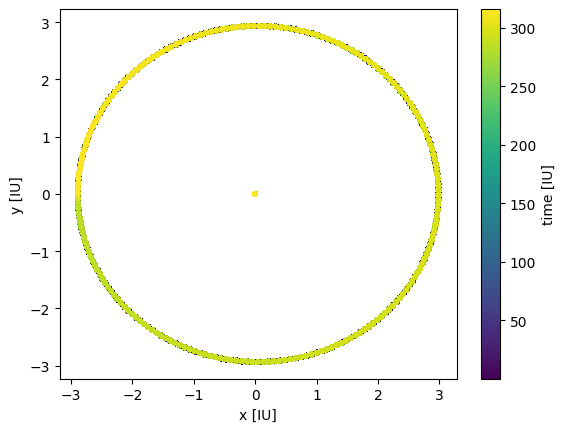

In [50]:
color = times
plt.scatter(m1_rows['x'],m1_rows['y'], c=color,  marker='.', alpha=0.5)
plt.scatter(m2_rows['x'],m2_rows['y'], c=color, marker='.', alpha=1)

plt.colorbar(label='time [IU]')
plt.xlabel('x [IU]')
plt.ylabel('y [IU]')


Text(0, 0.5, 'y [cm]')

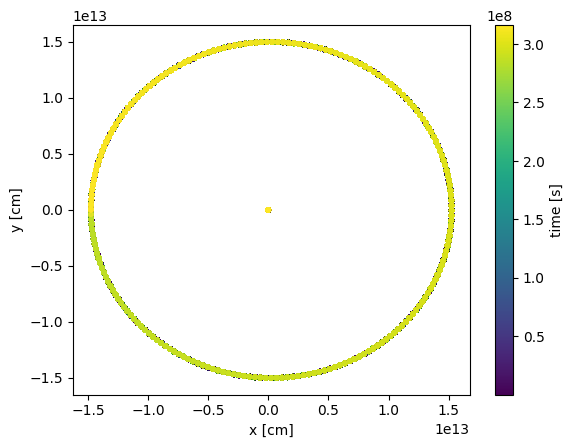

In [51]:
color = t_int_to_s(times)
plt.scatter(r_int_to_cm(m1_rows['x']),r_int_to_cm(m1_rows['y']), c=color,  marker='.', alpha=0.5)
plt.scatter(r_int_to_cm(m2_rows['x']),r_int_to_cm(m2_rows['y']), c=color, marker='.', alpha=1)

plt.colorbar(label='time [s]')
plt.xlabel('x [cm]')
plt.ylabel('y [cm]')

In [52]:
# comparison with analytical solution

In [53]:
x1 = np.array(m1_rows['x'])
x2 = np.array(m2_rows['x'])
y1 = np.array(m1_rows['y'])
y2 = np.array(m2_rows['y'])
aper = min(np.sqrt((x1-x2)**2+(y1-y2)**2))
aapo = max(np.sqrt((x1-x2)**2+(y1-y2)**2))

print(aper, aapo)

2.886399216743766 2.984441883533468


In [54]:
M = m1_rows.iloc[0]['m'] + m2_rows.iloc[0]['m']
mu = (m1_rows.iloc[0]['m'] * m2_rows.iloc[0]['m'])/M

In [55]:
e = (-aper+aapo)/(aper+aapo)
print('e =',e)

a = (aper+aapo)/2
print('a =',a)

Etot = -M/(2*a)
print('Etot =',Etot)

e = 0.016699935344029714
a = 2.935420550138617
Etot = -0.17033351489495732


In [56]:
def r(x1, y1, x2, y2):
    return np.sqrt((x1-x2)**2 + (y1-y2)**2)

In [57]:
rad = r(x1, y1, x2, y2)
vrad = r(np.array(m1_rows['vx']),np.array(m1_rows['vy']),np.array(m2_rows['vx']),np.array(m2_rows['vy']))

In [58]:
EG = -M*mu/rad
print(EG)
EK = 0.5*mu*vrad**2
print(EK)

[-3.46449862e-07 -3.46449862e-07 -3.46449862e-07 ... -3.46452404e-07
 -3.46452404e-07 -3.46450306e-07]
[1.76116528e-07 1.76116528e-07 1.76116528e-07 ... 1.76119067e-07
 1.76119067e-07 1.76116969e-07]


C:\Users\insta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\events.py:96: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\insta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


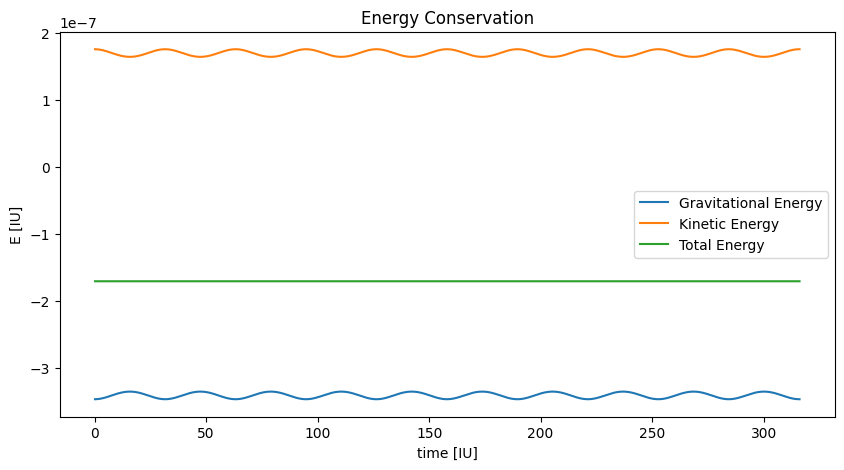

In [59]:
fig,ax = plt.subplots(1,1,figsize=(10,5))
plt.plot(times,EG,label='Gravitational Energy')
plt.plot(times,EK,label='Kinetic Energy')
plt.plot(times,EK+EG,label='Total Energy')
plt.xlabel('time [IU]')
plt.ylabel('E [IU]')
plt.title('Energy Conservation')
plt.legend()

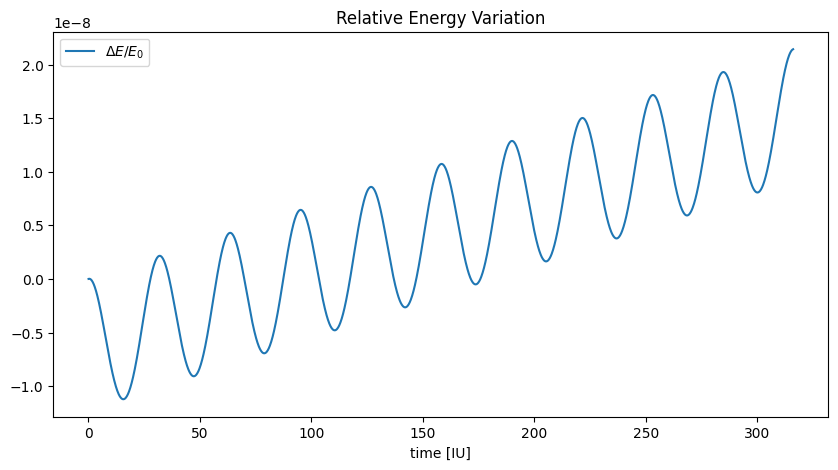

In [60]:
fig,ax = plt.subplots(1,1,figsize=(10,5))

plt.plot(times,(EK+EG-(EK[0]+EG[0]))/(EK[0]+EG[0]),label=r'$\Delta E/E_0$')
plt.xlabel('time [IU]')
plt.ylabel('')
plt.title('Relative Energy Variation')
plt.legend()